In [2]:
# Imports for Decision Tree Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.tree import export_text


# **Question-1**

# **Data Preparation**

In [3]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
try:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Purchase_new.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Purchase_new.csv", encoding='latin1')

df.head()

,Holiday,Discount,Free Delivery,Purchase
0,No,Yes,Yes,Yes
1,No,Yes,Yes,Yes
2,No,No,No,No
3,yes,Yes,Yes,Yes
4,yes,Yes,Yes,Yes


In [12]:
# Identify the input features and the target variable.
print("======================== Dataset Info ========================")
df.info()

# Dropping 'User ID' if it exists as it is not a predictive feature
if 'User ID' in df.columns:
    df = df.drop('User ID', axis=1)
    print("\nDropped 'User ID' column.")

print("\nTarget Variable: 'Purchase'")
print("Input Features:", list(df.columns[df.columns != 'Purchase']))

======================== Dataset Info ========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Holiday        30 non-null     object
 1   Discount       30 non-null     object
 2   Free Delivery  30 non-null     object
 3   Purchase       30 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB

Target Variable: 'Purchase'
Input Features: ['Holiday', 'Discount', 'Free Delivery']


In [9]:
# Task 2: Check for missing values and handle them if present.
print("No. of missing values BEFORE cleaning:\n", df.isnull().sum())

# Fill or drop missing values (dropping for baseline safety)
df.dropna(inplace=True)

print("\nNo. of missing values AFTER cleaning:\n", df.isnull().sum())

No. of missing values BEFORE cleaning:
 Holiday          0
Discount         0
Free Delivery    0
Purchase         0
dtype: int64

No. of missing values AFTER cleaning:
 Holiday          0
Discount         0
Free Delivery    0
Purchase         0
dtype: int64


In [14]:
# Task 2: Identify categorical and numerical features.
# Encode categorical variables using appropriate encoding techniques.

# We separate features and target
X = df.drop('Purchase', axis=1)
y = df['Purchase']

# Applying One-Hot Encoding to categorical variables (drop_first=True to avoid multicollinearity)
X = pd.get_dummies(X, drop_first=True)

print("Features Shape after Encoding:", X.shape)
display(X.head())

Features Shape after Encoding: (30, 3)


,Holiday_yes,Discount_Yes,Free Delivery_Yes
0,False,True,True
1,False,True,True
2,False,False,False
3,True,True,True
4,True,True,True


# **Data Splitting**

In [15]:
# Task 3: Split the dataset into training and testing sets using a 70:30 ratio.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training features shape: (21, 3)
Testing features shape: (9, 3)
Training labels shape: (21,)
Testing labels shape: (9,)


# **Train Model**

In [16]:
# Train Decision Tree using Gini index
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

# Train Decision Tree using Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


# **Models Evaluation**

In [19]:
# Predict using both models
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

# Print Evaluation for Gini
print("--- Gini Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Precision:", precision_score(y_test, y_pred_gini, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_gini, pos_label='Yes'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))

# Print Evaluation for Entropy
print("\n--- Entropy Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("Precision:", precision_score(y_test, y_pred_entropy, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_entropy, pos_label='Yes'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))

--- Gini Model Evaluation ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[1 0]
 [0 8]]

--- Entropy Model Evaluation ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[1 0]
 [0 8]]


# **Visualization**

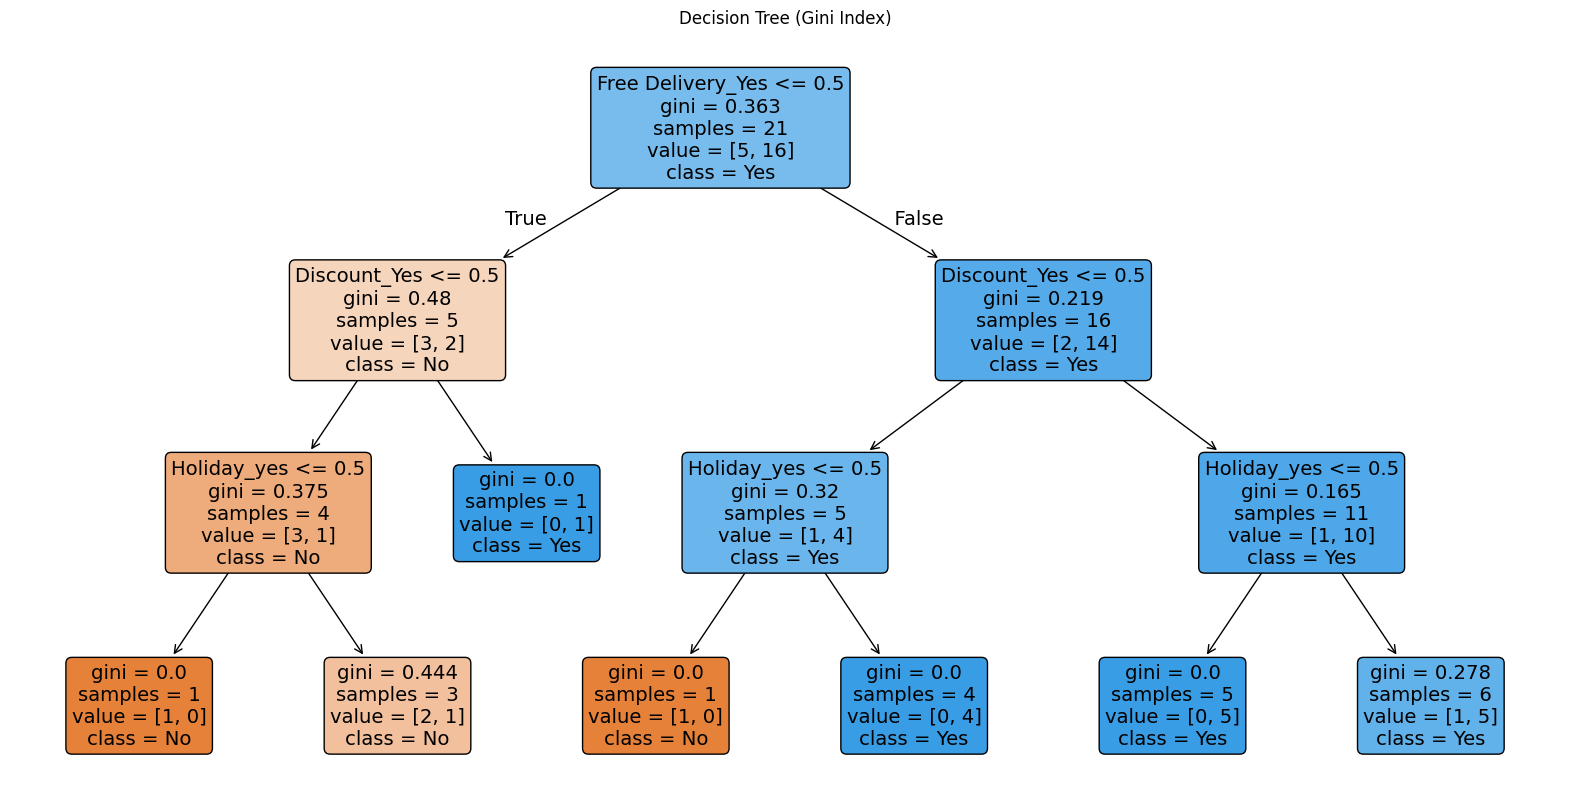

In [20]:
# Visualize the Gini Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_gini, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title("Decision Tree (Gini Index)")
plt.show()

In [21]:
# Export the decision rules of the Gini tree into text format
tree_rules = export_text(dt_gini, feature_names=list(X.columns))

# Print the rules so we can read them for our written answer
print("--- Decision Tree Rules (Root-to-Leaf) ---")
print(tree_rules)

--- Decision Tree Rules (Root-to-Leaf) ---
|--- Free Delivery_Yes <= 0.50
|   |--- Discount_Yes <= 0.50
|   |   |--- Holiday_yes <= 0.50
|   |   |   |--- class: No
|   |   |--- Holiday_yes >  0.50
|   |   |   |--- class: No
|   |--- Discount_Yes >  0.50
|   |   |--- class: Yes
|--- Free Delivery_Yes >  0.50
|   |--- Discount_Yes <= 0.50
|   |   |--- Holiday_yes <= 0.50
|   |   |   |--- class: No
|   |   |--- Holiday_yes >  0.50
|   |   |   |--- class: Yes
|   |--- Discount_Yes >  0.50
|   |   |--- Holiday_yes <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Holiday_yes >  0.50
|   |   |   |--- class: Yes



### **Task 7:**
*(Note: A condition to be true means the probablity is greater than 50%)*

**Path 1:** If there's no free delivery and there's no dicount, and there's no holday, then then the model predicts they will **NOT** purchase the car (Class: No)

**Path 2:** If there's no free delivery and there's a dicount, then the model predicts they **WILL** purchase the car (Class: Yes)

### **Task 8: Performance Comparison**



*   **Comparison:** Both models performed perfectly, achieving identical scores of 1.0 (100%) across all metrics (Accuracy, Precision, and Recall).
*   **Justification:** Since their performance is identical, the Gini index is the better choice. Its math is simpler (it avoids calculating logarithms), making it computationally faster and more efficient to train than Entropy.



# **Question-2**

## **Unrestricted Tree**

In [23]:
# Task 1: Train an unrestricted decision tree and record accuracies
dt_unrestricted = DecisionTreeClassifier(random_state=42)
dt_unrestricted.fit(X_train, y_train)

# Calculate training and testing accuracy
train_acc_un = accuracy_score(y_train, dt_unrestricted.predict(X_train))
test_acc_un = accuracy_score(y_test, dt_unrestricted.predict(X_test))

print(f"Unrestricted Tree - Training Accuracy: {train_acc_un:.4f}")
print(f"Unrestricted Tree - Testing Accuracy: {test_acc_un:.4f}")
print(f"Tree Depth: {dt_unrestricted.get_depth()}")

Unrestricted Tree - Training Accuracy: 0.9048
Unrestricted Tree - Testing Accuracy: 1.0000
Tree Depth: 3


## **Hyperparameter Tuning**

In [24]:
# Tasks 2 & 3: Train multiple models with different hyperparameters and compare
depths = [3, 5, 7]
splits = [2, 5, 10]
results = []

# Loop through all combinations of depth and splits
for d in depths:
    for s in splits:
        dt_tuned = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=42)
        dt_tuned.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, dt_tuned.predict(X_train))
        test_acc = accuracy_score(y_test, dt_tuned.predict(X_test))

        # Store results in a list
        results.append({'max_depth': d, 'min_samples_split': s,
                        'train_acc': train_acc, 'test_acc': test_acc})

# Display results as a readable table
results_df = pd.DataFrame(results)
display(results_df)

,max_depth,min_samples_split,train_acc,test_acc
0,3,2,0.904762,1.000000
1,3,5,0.904762,1.000000
2,3,10,0.809524,0.888889
3,5,2,0.904762,1.000000
4,5,5,0.904762,1.000000
5,5,10,0.809524,0.888889
6,7,2,0.904762,1.000000
7,7,5,0.904762,1.000000
8,7,10,0.809524,0.888889


## **Plotting Depth vs. Accuracy**

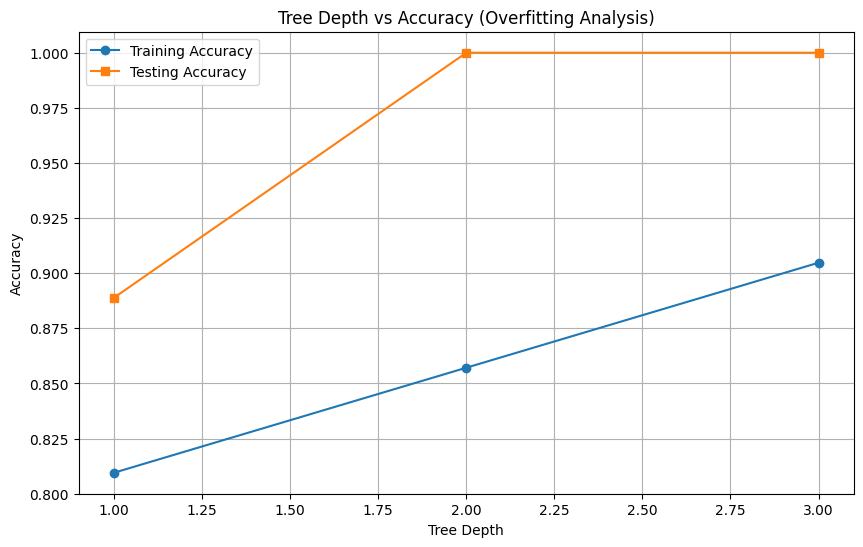

In [25]:
# Task 4: Plot the relationship between tree depth and accuracy
max_depth_range = range(1, dt_unrestricted.get_depth() + 1)
train_scores, test_scores = [], []

# Train a model for every depth from 1 to the maximum depth
for d in max_depth_range:
    dt_plot = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_plot.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_plot.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt_plot.predict(X_test)))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, train_scores, marker='o', label='Training Accuracy')
plt.plot(max_depth_range, test_scores, marker='s', label='Testing Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Tree Depth vs Accuracy (Overfitting Analysis)')
plt.legend()
plt.grid(True)
plt.show()

## **Cost-Complexity Pruning**

In [26]:
# Task 5: Get all possible pruning alphas
path = dt_unrestricted.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

pruned_trees = []
# Train a tree for each alpha value
for alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_pruned.fit(X_train, y_train)
    pruned_trees.append(dt_pruned)

# Evaluate all pruned trees on the test set
test_accs = [accuracy_score(y_test, tree.predict(X_test)) for tree in pruned_trees]

# Task 6: Identify the optimal model
best_index = np.argmax(test_accs) # Finds the index of the highest accuracy
best_tree = pruned_trees[best_index]
best_alpha = ccp_alphas[best_index]

print(f"Optimal ccp_alpha: {best_alpha:.5f}")
print(f"Optimal Test Accuracy: {test_accs[best_index]:.4f}")
print(f"Depth of Optimal Pruned Tree: {best_tree.get_depth()}")

Optimal ccp_alpha: 0.00000
Optimal Test Accuracy: 1.0000
Depth of Optimal Pruned Tree: 3


### **Question 2 Analysis**

**Task 7: Overfitting and Pruning**
*   **Overfitting** happens when a tree memorizes training data (including noise), leading to poor performance on new data. **Pruning** simplifies the tree by cutting weak branches to fix this.
*   *Our Results:* The optimal `ccp_alpha` was 0.00000. The tree generalized perfectly at a shallow depth (Depth 3) and didn't overfit, so pruning wasn't needed.

**Task 8: Hyperparameter Impact**
*   **`max_depth`** had the biggest impact. The plot shows testing accuracy hit 100% just by increasing depth from 1 to 2. Since the dataset is easily solved at shallow depths, changing `min_samples_split` had practically no effect.